In [ ]:
# %% [markdown]
# Instalação estável do Prophet no Colab (sem recompilar Stan)
!pip install prophet==1.1.5 lightgbm catboost tqdm


In [ ]:
# Corrige compatibilidade do Prophet com NumPy 2.0+
import numpy as np
if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "int_"):
    np.int_ = np.int64
if not hasattr(np, "bool_"):
    np.bool_ = np.bool_


In [ ]:
# CONFIGS
DATA_PATH = "/content"  # pasta com os CSVs
PARAMETRO_ALVO = "TPT-P"
COLUNA_TEMPO = "datetime"
TRAIN_SPLIT = 0.9
TEST_MIN_STEPS = 200                     # mínimo de pontos no teste
RESAMPLE = True
FREQUENCIA = "D"                        # muda para diária
RESAMPLE_AGG = "median"                 # professor Thales recomendou mediana

RESAMPLE_AGG = "median"

# Lags/rolling p/ modelos baseados em árvore
LAGS_CURTOS = [1, 2, 3, 6, 12]
LAGS_SAZONAIS = [24, 48, 72, 168]
ROLL_WINDOWS = [3, 6, 12, 24]

# Controle de gráficos e saving
GERAR_GRAFICOS = False
SALVAR_RESULTADOS_CSV = False
RESULTS_CSV_PATH = "/mnt/data/resultados_comparacao_modelos.csv"
RANDOM_STATE = 42


In [ ]:
# Imports e funções utilitárias
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm import tqdm

from prophet import Prophet
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
np.random.seed(RANDOM_STATE)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0: return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

def add_time_features(df):
    out = df.copy()
    out["year"]  = out["ds"].dt.year
    out["month"] = out["ds"].dt.month
    out["day"]   = out["ds"].dt.day
    out["hour"]  = out["ds"].dt.hour
    out["dow"]   = out["ds"].dt.dayofweek
    out["week"]  = out["ds"].dt.isocalendar().week.astype(int)
    return out

def add_lag_features(df, lags, roll_windows):
    out = df.copy()
    for l in lags:
        out[f"lag_{l}"] = out["y"].shift(l)
    for w in roll_windows:
        out[f"rmean_{w}"] = out["y"].shift(1).rolling(w).mean()
        out[f"rstd_{w}"]  = out["y"].shift(1).rolling(w).std()
    return out

def plot_pred(df_train, df_test, yhat, titulo=""):
    plt.figure(figsize=(12,4))
    plt.plot(df_train["ds"], df_train["y"], label="Treino")
    plt.plot(df_test["ds"], df_test["y"], label="Real (Teste)")
    plt.plot(df_test["ds"], yhat, label="Previsão")
    plt.title(titulo); plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
# Loader de séries (com DatetimeIndex antes de interpolação "time")
def carregar_serie(filepath, col_tempo, col_valor, do_resample=False, freq="H", agg="median"):
    df = pd.read_csv(filepath)


    if col_valor not in df.columns:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if col_tempo in num_cols:
            num_cols.remove(col_tempo)
        if len(num_cols) == 0:
            raise ValueError(f"Nenhuma coluna numérica encontrada em {os.path.basename(filepath)}")
        print(f"[Aviso] Coluna '{col_valor}' não encontrada em {os.path.basename(filepath)}. Usando '{num_cols[0]}'")
        col_valor = num_cols[0]


    if col_tempo not in df.columns:
        possiveis = [c for c in df.columns if any(k in c.lower() for k in ["time","data","date","datetime","timestamp"])]
        if not possiveis:
            raise ValueError(f"Não foi possível identificar coluna de tempo em {os.path.basename(filepath)}.")
        col_tempo = possiveis[0]
        print(f"[Aviso] Usando '{col_tempo}' como coluna de tempo para {os.path.basename(filepath)}")

    df[col_tempo] = pd.to_datetime(df[col_tempo], errors="coerce")
    df = df.dropna(subset=[col_tempo])

    df = df[[col_tempo, col_valor]].dropna()
    df = df.rename(columns={col_tempo: "ds", col_valor: "y"})
    df = df.sort_values("ds").drop_duplicates(subset=["ds"])


    df = df.set_index("ds")

    if do_resample:
        if agg == "mean": df = df.resample(freq).mean()
        elif agg == "sum": df = df.resample(freq).sum()
        else: df = df.resample(freq).median()


    df["y"] = df["y"].interpolate(method="time").bfill().ffill()

    # volta 'ds' como coluna
    df = df.reset_index()
    df["y"] = df["y"].astype(float)
    return df

def split_train_test(df, train_split=0.9, test_min=100):
    n = len(df)
    split_idx = max(int(n * train_split), n - test_min)
    train = df.iloc[:split_idx].copy()
    test  = df.iloc[split_idx:].copy()
    return train, test


In [ ]:
# Modelo 1 — Prophet
def fit_forecast_prophet(train_df, test_df):
    # Usa toda a série (dados diários)
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
        seasonality_mode="additive",
    )
    m.add_seasonality(name="mensal", period=30.5, fourier_order=6)
    m.add_seasonality(name="trimestral", period=90, fourier_order=4)
    m.fit(train_df[["ds", "y"]], iter=2000)

    future = pd.DataFrame({"ds": test_df["ds"].values})
    forecast = m.predict(future)
    return forecast["yhat"].values



In [ ]:
# Modelo 2 — Híbrido Prophet + LGBM
def fit_forecast_prophet_lgbm(train_df, test_df):
    # 1) Prophet simplificado
    if len(train_df) > 2000:
        train_df = train_df.iloc[-2000:]

    mp = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.2,
        seasonality_mode="additive",
    )
    mp.add_seasonality(name="mensal", period=30.5, fourier_order=3)
    mp.fit(train_df[["ds","y"]], iter=1000)

    # 2) Calcula resíduo no treino
    train_fc = mp.predict(train_df[["ds"]])
    train_resid = train_df.copy()
    train_resid["prophet_yhat"] = train_fc["yhat"].values
    train_resid["resid"] = train_resid["y"] - train_resid["prophet_yhat"]

    resid_df = add_time_features(train_resid)
    resid_df = add_lag_features(resid_df, LAGS_CURTOS + [24, 48, 72], [3, 6, 12])
    resid_df = resid_df.dropna().reset_index(drop=True)

    feats = [c for c in resid_df.columns if c not in ["ds","y","prophet_yhat","resid"]]
    X_train = resid_df[feats]
    y_train = resid_df["resid"]

    lgbm = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    )
    lgbm.fit(X_train, y_train)

    # 3) Previsão Prophet no teste
    test_fc = mp.predict(test_df[["ds"]])
    prophet_yhat = test_fc["yhat"].values

    # 4) Previsão LGBM sobre resíduos
    df_all = pd.concat([train_df[["ds","y"]], test_df[["ds"]]], ignore_index=True)
    df_all["y"] = df_all["y"].ffill()  # preenche apenas com históricos do treino
    df_all = add_time_features(df_all)

    df_all = add_lag_features(df_all, LAGS_CURTOS + [24, 48, 72], [3,6,12])
    df_all = df_all.dropna().reset_index(drop=True)

    X_all = df_all[feats]
    resid_preds = lgbm.predict(X_all.iloc[-len(test_df):])

    yhat = prophet_yhat + resid_preds
    return yhat


In [ ]:
# Modelo 3 — CatBoost com lags + calendário (previsão recursiva)
def fit_forecast_catboost(train_df, test_df):
    full = pd.concat([train_df.copy(), test_df.copy()], ignore_index=True)
    full = add_time_features(full)
    full = add_lag_features(full, LAGS_CURTOS + LAGS_SAZONAIS, ROLL_WINDOWS)

    n_train = len(train_df)
    train_block = full.iloc[:n_train].dropna().copy()

    feats = [c for c in train_block.columns if c not in ["ds","y"]]
    X_train = train_block[feats]
    y_train = train_block["y"]

    model = CatBoostRegressor(
    depth=10,
    learning_rate=0.02,
    n_estimators=1800,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    l2_leaf_reg=5,
    verbose=False
)
    model.fit(X_train, y_train)

    preds = []
    for i in range(n_train, len(full)):
        hist = full.iloc[:i].copy()
        hist = add_time_features(hist)
        hist = add_lag_features(hist, LAGS_CURTOS + LAGS_SAZONAIS, ROLL_WINDOWS)
        last = hist.dropna().iloc[[-1]]
        if last.empty:
            # fallback: mantém último valor conhecido
            pred = float(hist["y"].dropna().iloc[-1]) if hist["y"].notna().any() else float(y_train.iloc[-1])
        else:
            X_last = last[[c for c in last.columns if c not in ["ds","y"]]]
            pred = float(model.predict(X_last)[0])
        preds.append(pred)
        # injeta previsão como y (feed-forward para lags)
        full.loc[i, "y"] = pred

    return np.array(preds)


In [ ]:
from prophet import Prophet
import pandas as pd, numpy as np

print("🛠️ Compilando Prophet em modo rápido (isso leva ~1 min apenas)...")

dummy = pd.DataFrame({
    "ds": pd.date_range("2020-01-01", periods=30, freq="D"),
    "y": np.random.randn(30)
})

_prophet_cache = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.2,
    seasonality_mode="additive",
)
_prophet_cache.add_seasonality(name="mensal", period=30.5, fourier_order=3)
_prophet_cache.fit(dummy, iter=200)

print("✅ Prophet pré-compilado — pronto para uso.")


INFO:prophet:n_changepoints greater than number of observations. Using 23.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkw9nxaoy/x1467qxn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkw9nxaoy/ugfanzs2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=94518', 'data', 'file=/tmp/tmpkw9nxaoy/x1467qxn.json', 'init=/tmp/tmpkw9nxaoy/ugfanzs2.json', 'output', 'file=/tmp/tmpkw9nxaoy/prophet_model0qzj8lh0/prophet_model-20251008134350.csv', 'method=optimize', 'algorithm=newton', 'iter=200']
13:43:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:43:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


🛠️ Compilando Prophet em modo rápido (isso leva ~1 min apenas)...
✅ Prophet pré-compilado — pronto para uso.


In [ ]:
# Loop principal — lê todos CSVs, treina/prevê e avalia os 3 modelos
import time

print("\n" + "="*60)
print("🚀 INICIANDO PROCESSAMENTO DOS POÇOS")
print("="*60)

csv_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
print(f"Encontrados {len(csv_files)} arquivos CSV:")
for file in csv_files:
    print(f"  - {os.path.basename(file)}")

result_rows = []

for idx, path in enumerate(csv_files, start=1):
    nome_poco = os.path.splitext(os.path.basename(path))[0]
    print(f"\n{'-'*60}")
    print(f"🔹 [{idx}/{len(csv_files)}] Processando poço: {nome_poco}")
    start_poco = time.time()

    try:
        # Carrega série
        df = carregar_serie(
            filepath=path,
            col_tempo=COLUNA_TEMPO,
            col_valor=PARAMETRO_ALVO,
            do_resample=RESAMPLE,
            freq=FREQUENCIA,
            agg=RESAMPLE_AGG
        )

        if len(df) < 300:
            print(f"[Aviso] Série muito curta ({len(df)}) em {nome_poco}, pulando.")
            continue

        print(f"📈 Série carregada ({len(df)} pontos). Iniciando treino/teste split...")
        train_df, test_df = split_train_test(df, TRAIN_SPLIT, TEST_MIN_STEPS)

        # ===== Prophet =====
        print("⚙️  Rodando modelo 1/3 → Prophet...")
        t0 = time.time()
        yhat_prophet = fit_forecast_prophet(train_df, test_df)
        print(f"✅ Prophet concluído em {time.time()-t0:.2f} s")

        # ===== Híbrido Prophet + LGBM =====
        print("⚙️  Rodando modelo 2/3 → Híbrido Prophet+LGBM...")
        t0 = time.time()
        yhat_hibrido = fit_forecast_prophet_lgbm(train_df, test_df)
        print(f"✅ Híbrido concluído em {time.time()-t0:.2f} s")

        # ===== CatBoost =====
        print("⚙️  Rodando modelo 3/3 → CatBoost...")
        t0 = time.time()
        yhat_cat = fit_forecast_catboost(train_df, test_df)
        print(f"✅ CatBoost concluído em {time.time()-t0:.2f} s")

        # ===== Avaliação =====
        y_true = test_df["y"].values
        row = dict(
            poco=nome_poco, n_train=len(train_df), n_test=len(test_df),
            Prophet_MAE = mean_absolute_error(y_true, yhat_prophet),
            Prophet_RMSE= rmse(y_true, yhat_prophet),
            Prophet_MAPE= mape(y_true, yhat_prophet),
            Hibrido_MAE = mean_absolute_error(y_true, yhat_hibrido),
            Hibrido_RMSE= rmse(y_true, yhat_hibrido),
            Hibrido_MAPE= mape(y_true, yhat_hibrido),
            CatBoost_MAE = mean_absolute_error(y_true, yhat_cat),
            CatBoost_RMSE= rmse(y_true, yhat_cat),
            CatBoost_MAPE= mape(y_true, yhat_cat),
            # 👇 adiciona previsões e dados reais para os gráficos
            y_true=list(y_true),
            yhat_prophet=list(yhat_prophet),
            yhat_hibrido=list(yhat_hibrido),
            yhat_cat=list(yhat_cat),
            test_dates=list(test_df['ds'])
        )
        result_rows.append(row)

        if GERAR_GRAFICOS:
            plot_pred(train_df, test_df, yhat_prophet, f"{nome_poco} — Prophet")
            plot_pred(train_df, test_df, yhat_hibrido, f"{nome_poco} — Híbrido Prophet+LGBM")
            plot_pred(train_df, test_df, yhat_cat,     f"{nome_poco} — CatBoost")

        print(f"🕒 Poço {nome_poco} concluído em {time.time()-start_poco:.2f} s")

    except Exception as e:
        print(f"[❌ Erro] {nome_poco}: {e}")

    finally:
        import gc
        for var in ["df","train_df","test_df","yhat_prophet","yhat_hibrido","yhat_cat"]:
            if var in locals():
                del locals()[var]
        gc.collect()

print("\n" + "="*60)
print("✅ PROCESSAMENTO CONCLUÍDO")
print("="*60)

# (Opcional) gera dataframe final de resultados
results = pd.DataFrame(result_rows)
if len(results) > 0:
    results_sorted = results.sort_values(["Hibrido_RMSE"]).reset_index(drop=True)
    print("\n🏁 Ranking (menor RMSE primeiro):")
    display(results_sorted)
    if SALVAR_RESULTADOS_CSV:
        results_sorted.to_csv(RESULTS_CSV_PATH, index=False)
        print(f"\n💾 Resultados salvos em: {RESULTS_CSV_PATH}")



🚀 INICIANDO PROCESSAMENTO DOS POÇOS
Encontrados 6 arquivos CSV:
  - LL-22.csv
  - SPH-6.csv
  - SPH-8.csv
  - LL-11.csv
  - SPS-77.csv
  - SPH-2.csv

------------------------------------------------------------
🔹 [1/6] Processando poço: LL-22


DEBUG:cmdstanpy:input tempfile: /tmp/tmpkw9nxaoy/g8x5jml2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkw9nxaoy/zrdfesau.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=6366', 'data', 'file=/tmp/tmpkw9nxaoy/g8x5jml2.json', 'init=/tmp/tmpkw9nxaoy/zrdfesau.json', 'output', 'file=/tmp/tmpkw9nxaoy/prophet_modelo1i26j4t/prophet_model-20251008134401.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=2000']
13:44:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


📈 Série carregada (2259 pontos). Iniciando treino/teste split...
⚙️  Rodando modelo 1/3 → Prophet...


13:44:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkw9nxaoy/_m_czref.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkw9nxaoy/kpxt61av.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69682', 'data', 'file=/tmp/tmpkw9nxaoy/_m_czref.json', 'init=/tmp/tmpkw9nxaoy/kpxt61av.json', 'output', 'file=/tmp/tmpkw9nxaoy/prophet_modeldxuey4vl/prophet_model-20251008134402.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=1000']
13:44:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:44:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


✅ Prophet concluído em 0.52 s
⚙️  Rodando modelo 2/3 → Híbrido Prophet+LGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000386 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3683
[LightGBM] [Info] Number of data points in the train set: 1928, number of used features: 19
[LightGBM] [Info] Start training from score 0.058741
✅ Híbrido concluído em 0.80 s
⚙️  Rodando modelo 3/3 → CatBoost...
✅ CatBoost concluído em 73.12 s
🕒 Poço LL-22 concluído em 76.09 s

------------------------------------------------------------
🔹 [2/6] Processando poço: SPH-6


...

DEBUG:cmdstanpy:input tempfile: /tmp/tmpkw9nxaoy/bzs_b41l.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=1037', 'data', 'file=/tmp/tmpkw9nxaoy/4wr71zlx.json', 'init=/tmp/tmpkw9nxaoy/bzs_b41l.json', 'output', 'file=/tmp/tmpkw9nxaoy/prophet_modelflomknmo/prophet_model-20251008135024.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=2000']
13:50:24 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:50:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkw9nxaoy/c8wrmsso.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkw9nxaoy/_ahxx5qi.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin

✅ Prophet concluído em 1.01 s
⚙️  Rodando modelo 2/3 → Híbrido Prophet+LGBM...


13:50:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000307 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3682
[LightGBM] [Info] Number of data points in the train set: 1572, number of used features: 19
[LightGBM] [Info] Start training from score 0.197844
✅ Híbrido concluído em 0.87 s
⚙️  Rodando modelo 3/3 → CatBoost...
✅ CatBoost concluído em 73.32 s
🕒 Poço SPH-2 concluído em 77.39 s

✅ PROCESSAMENTO CONCLUÍDO

🏁 Ranking (menor RMSE primeiro):


,poco,n_train,n_test,Prophet_MAE,Prophet_RMSE,Prophet_MAPE,Hibrido_MAE,Hibrido_RMSE,Hibrido_MAPE,CatBoost_MAE,CatBoost_RMSE,CatBoost_MAPE,y_true,yhat_prophet,yhat_hibrido,yhat_cat,test_dates
0,SPS-77,2125,200,21.717446,22.867472,11.531605,14.716690,15.869477,7.788606,11.559570,19.665397,6.150010,"[186.19475517249998, 186.155001835, 186.190529...","[223.4775569058798, 218.58322384112182, 214.44...","[148.6984839557259, 188.66835872045965, 189.11...","[187.27188162501898, 193.7633982351491, 202.15...","[2019-12-08 00:00:00, 2019-12-09 00:00:00, 201..."
1,LL-11,2387,200,97.166663,100.129470,55.520089,12.166022,16.303582,6.747673,43.963379,45.133490,25.198940,"[179.34550133582823, 179.3574982002009, 179.52...","[249.5499109922282, 250.9937318306049, 250.699...","[178.95751853029333, 178.6685366209914, 169.33...","[175.41267553129074, 173.6749682953595, 186.62...","[2019-12-06 00:00:00, 2019-12-07 00:00:00, 201..."
2,SPH-6,1603,179,23.048646,27.771896,12.622440,13.060454,18.106793,6.930814,13.127501,16.708250,7.245938,"[185.213934315, 185.29781189, 185.281036375, 1...","[199.9356614831434, 200.67620530308938, 201.12...","[168.1322333425301, 170.7917355703733, 170.317...","[185.51245465526412, 184.69130204055355, 190.9...","[2020-01-17 00:00:00, 2020-01-18 00:00:00, 202..."
3,LL-22,2059,200,12.934976,19.685316,5.291689,10.976151,18.263203,4.430330,24.098740,26.152278,10.498060,"[229.0391014362703, 266.5011922725905, 229.963...","[238.05687081033156, 238.02754591428172, 234.1...","[231.08343587521324, 224.34902427584274, 222.4...","[229.06500426700183, 230.1790232549262, 229.83...","[2019-12-27 00:00:00, 2019-12-28 00:00:00, 201..."
4,SPH-8,1681,187,19.462946,23.355185,8.725632,20.335224,25.697241,9.022924,10.977385,12.818958,5.138653,"[199.64123304, 199.59205627, 199.5749015725, 1...","[190.25925072698467, 191.8876344178085, 190.87...","[198.96358827964764, 198.23376667454397, 196.8...","[200.19539188107558, 200.4289973170549, 201.12...","[2019-12-17 00:00:00, 2019-12-18 00:00:00, 201..."
5,SPH-2,1644,183,83.486129,117.295938,23.976133,82.455698,122.789202,22.428238,79.758351,113.170387,22.709054,"[195.9243674975, 195.882052615, 195.8420249775...","[203.67181032495364, 203.9073823902659, 205.44...","[196.93298492573373, 196.7507989425619, 196.74...","[196.83259991098117, 197.0047997563321, 197.36...","[2019-12-26 00:00:00, 2019-12-27 00:00:00, 201..."


In [ ]:
# 📊 RESUMO DAS MÉTRICAS POR POÇO (3 MODELOS COMPARATIVOS)
print("📊 RESUMO DAS MÉTRICAS POR POÇO (3 MODELOS COMPARATIVOS)")
print("=" * 100)
print(f"{'Poço':<10} {'Prophet MAE':<13} {'Híbrido MAE':<13} {'CatBoost MAE':<13} "
      f"{'Prophet MAPE':<14} {'Híbrido MAPE':<14} {'CatBoost MAPE':<14}")
print("-" * 100)

# Listas para armazenar métricas válidas
metrics_prophet = []
metrics_hibrido = []
metrics_catboost = []

# Iterar pelos poços e exibir métricas individuais
for _, row in results.iterrows():
    poco = row["poco"]

    # Acessar métricas com verificação de existência
    prophet_mae = row.get("Prophet_MAE", np.nan)
    hibrido_mae = row.get("Hibrido_MAE", np.nan)
    cat_mae = row.get("CatBoost_MAE", np.nan)

    prophet_mape = row.get("Prophet_MAPE", np.nan)
    hibrido_mape = row.get("Hibrido_MAPE", np.nan)
    cat_mape = row.get("CatBoost_MAPE", np.nan)

    # Impressão formatada (com “-” para valores ausentes)
    def fmt(x, dec=4): return f"{x:.{dec}f}" if pd.notna(x) else "-"
    print(f"{poco:<10} {fmt(prophet_mae):<13} {fmt(hibrido_mae):<13} {fmt(cat_mae):<13} "
          f"{fmt(prophet_mape,2):<14} {fmt(hibrido_mape,2):<14} {fmt(cat_mape,2):<14}")

    # Adiciona aos conjuntos de métricas válidas
    if pd.notna(prophet_mae): metrics_prophet.append({"MAE": prophet_mae, "MAPE": prophet_mape})
    if pd.notna(hibrido_mae): metrics_hibrido.append({"MAE": hibrido_mae, "MAPE": hibrido_mape})
    if pd.notna(cat_mae): metrics_catboost.append({"MAE": cat_mae, "MAPE": cat_mape})

# MÉDIAS GERAIS
def avg(lst, key): return np.mean([d[key] for d in lst]) if lst else np.nan

avg_mae_prophet = avg(metrics_prophet, "MAE")
avg_mae_hibrido = avg(metrics_hibrido, "MAE")
avg_mae_cat = avg(metrics_catboost, "MAE")

avg_mape_prophet = avg(metrics_prophet, "MAPE")
avg_mape_hibrido = avg(metrics_hibrido, "MAPE")
avg_mape_cat = avg(metrics_catboost, "MAPE")

print("-" * 100)
print(f"{'MÉDIA':<10} {fmt(avg_mae_prophet):<13} {fmt(avg_mae_hibrido):<13} {fmt(avg_mae_cat):<13} "
      f"{fmt(avg_mape_prophet,2):<14} {fmt(avg_mape_hibrido,2):<14} {fmt(avg_mape_cat,2):<14}")
print("=" * 100)

# ANÁLISE COMPARATIVA
valid_models = []
if not np.isnan(avg_mae_prophet): valid_models.append(('Prophet', avg_mae_prophet))
if not np.isnan(avg_mae_hibrido): valid_models.append(('Híbrido', avg_mae_hibrido))
if not np.isnan(avg_mae_cat): valid_models.append(('CatBoost', avg_mae_cat))

if valid_models:
    best_model = min(valid_models, key=lambda x: x[1])
    worst_model = max(valid_models, key=lambda x: x[1])

    print(f"\n🎯 ANÁLISE COMPARATIVA DOS MODELOS:")
    print(f"   🥇 Melhor modelo (MAE): {best_model[0]} ({best_model[1]:.4f})")
    print(f"   🥉 Pior modelo (MAE):   {worst_model[0]} ({worst_model[1]:.4f})")

    if len(valid_models) > 1:
        improvement = ((worst_model[1] - best_model[1]) / worst_model[1]) * 100
        print(f"   📈 Melhoria: {improvement:.2f}% ({worst_model[0]} → {best_model[0]})")

    total_wells = len(results)
    print(f"   📊 Modelos válidos: {len(valid_models)}/3")
    print(f"   📍 Poços processados: {total_wells}")

    # Taxa de sucesso
    print(f"\n📈 TAXA DE SUCESSO POR MODELO:")
    print(f"   Prophet: {len(metrics_prophet)}/{total_wells} ({len(metrics_prophet)/total_wells*100:.1f}%)")
    print(f"   Híbrido: {len(metrics_hibrido)}/{total_wells} ({len(metrics_hibrido)/total_wells*100:.1f}%)")
    print(f"   CatBoost: {len(metrics_catboost)}/{total_wells} ({len(metrics_catboost)/total_wells*100:.1f}%)")
    print("=" * 100)
else:
    print("⚠️ Nenhum resultado válido encontrado. Verifique se os modelos foram executados corretamente.")


📊 RESUMO DAS MÉTRICAS POR POÇO (3 MODELOS COMPARATIVOS)
Poço       Prophet MAE   Híbrido MAE   CatBoost MAE  Prophet MAPE   Híbrido MAPE   CatBoost MAPE 
----------------------------------------------------------------------------------------------------
LL-22      12.9350       10.9762       24.0987       5.29           4.43           10.50         
SPH-6      23.0486       13.0605       13.1275       12.62          6.93           7.25          
SPH-8      19.4629       20.3352       10.9774       8.73           9.02           5.14          
LL-11      97.1667       12.1660       43.9634       55.52          6.75           25.20         
SPS-77     21.7174       14.7167       11.5596       11.53          7.79           6.15          
SPH-2      83.4861       82.4557       79.7584       23.98          22.43          22.71         
----------------------------------------------------------------------------------------------------
MÉDIA      42.9695       25.6184       30.5808       19.


📊 CRIANDO VISUALIZAÇÕES COMPARATIVAS — Prophet x Híbrido x CatBoost

📈 Criando gráfico geral de performance por poço...


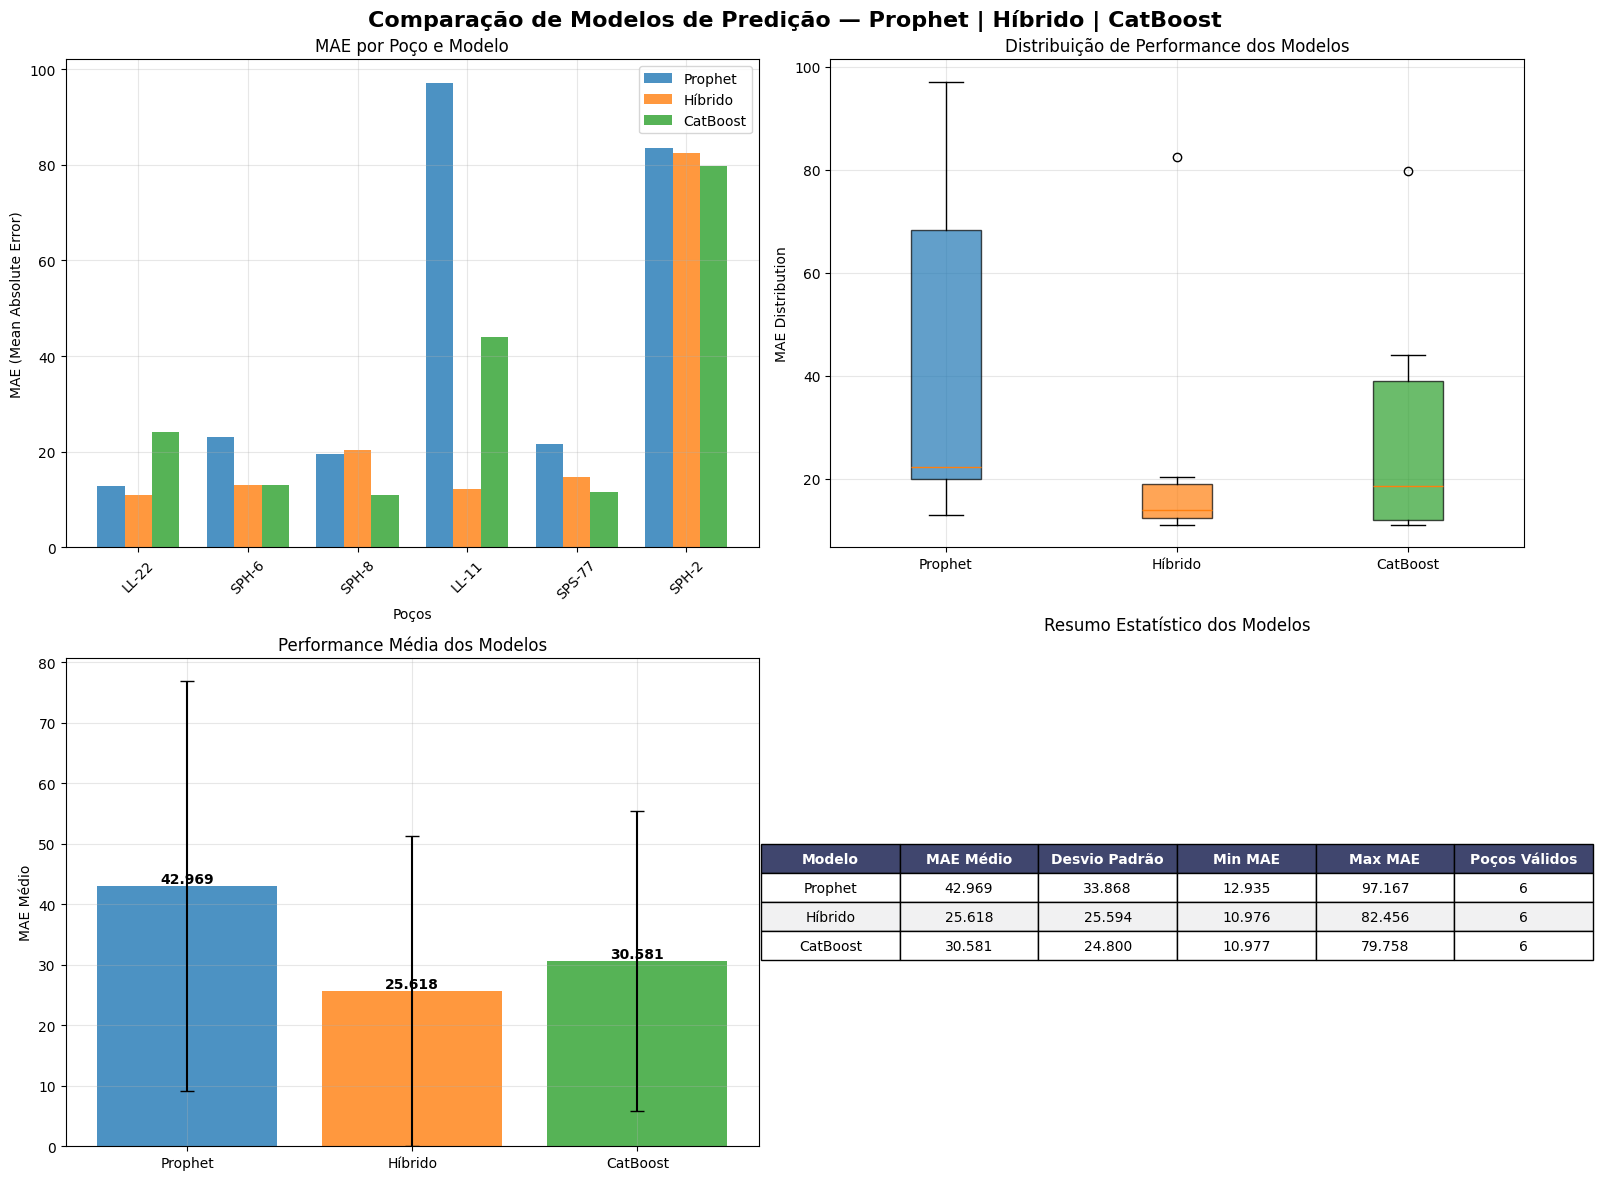

✅ Gráfico geral criado com sucesso!

📊 Criando gráficos individuais para os primeiros poços...
   📈 Plotando LL-22...


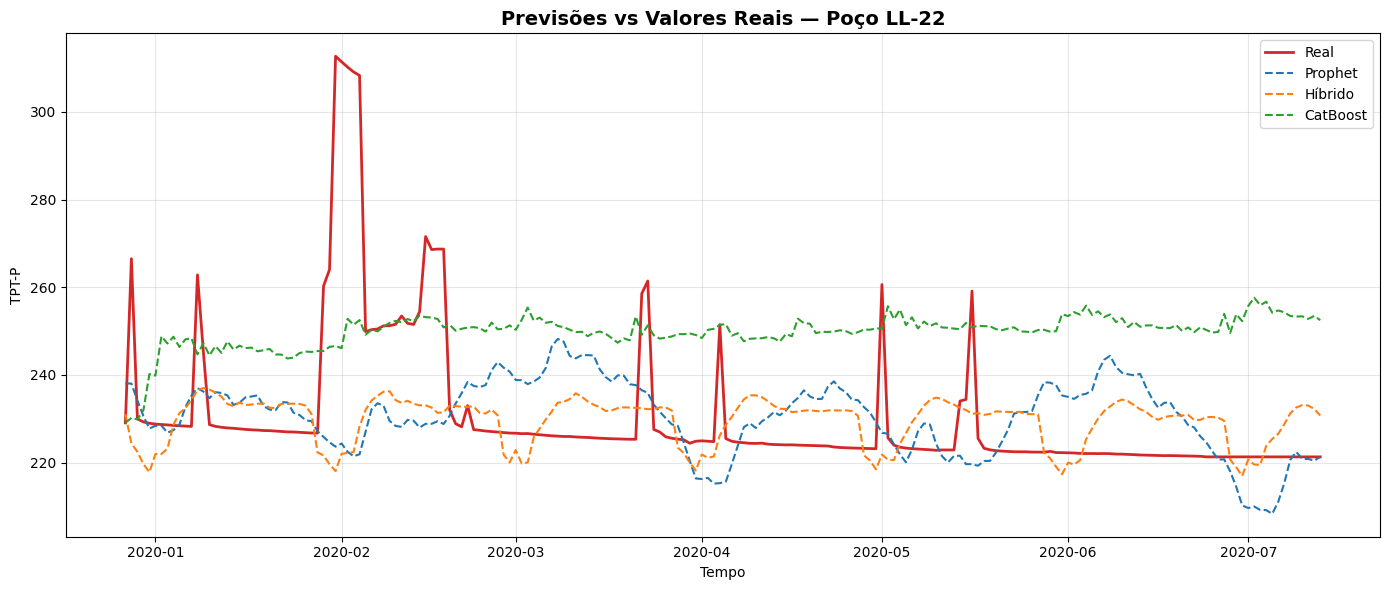

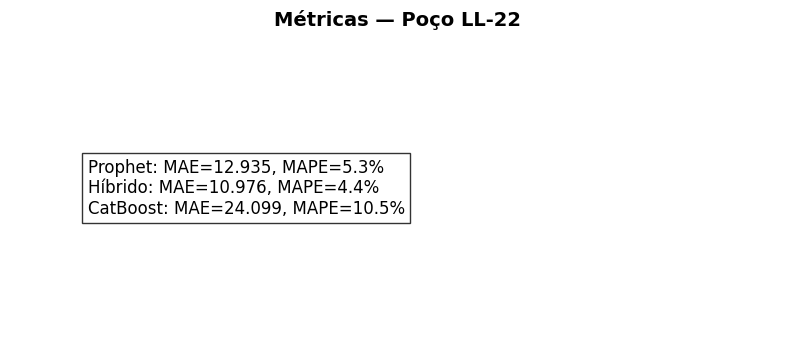

   📈 Plotando SPH-6...


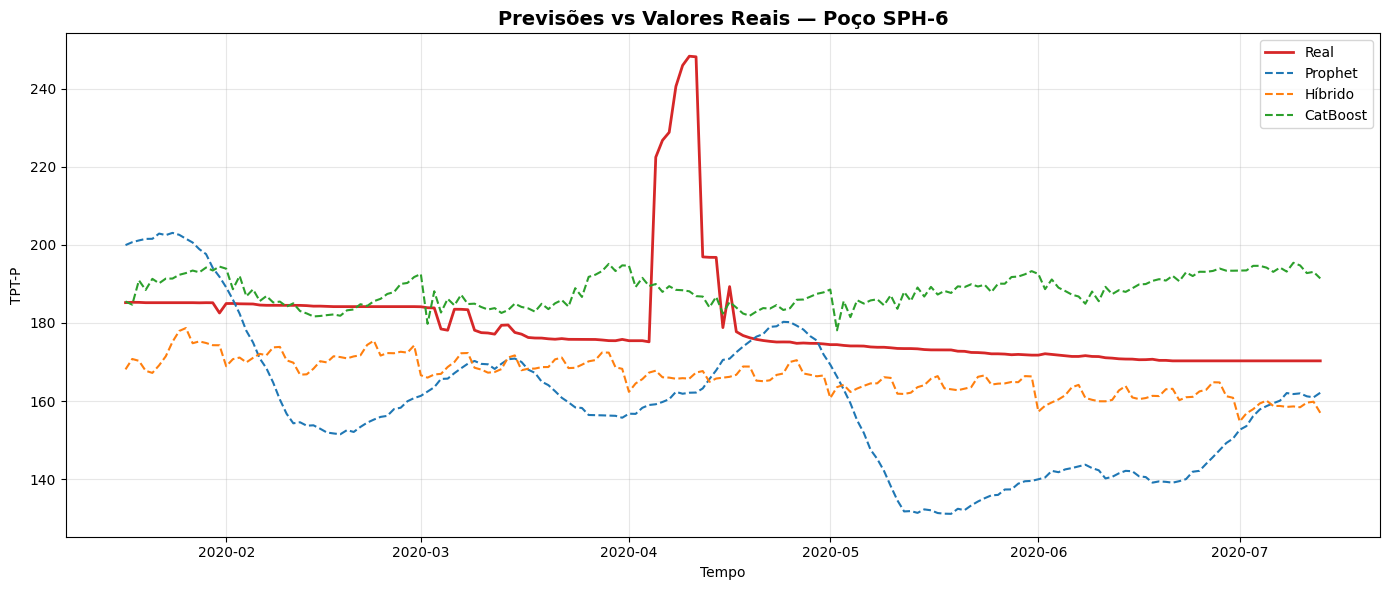

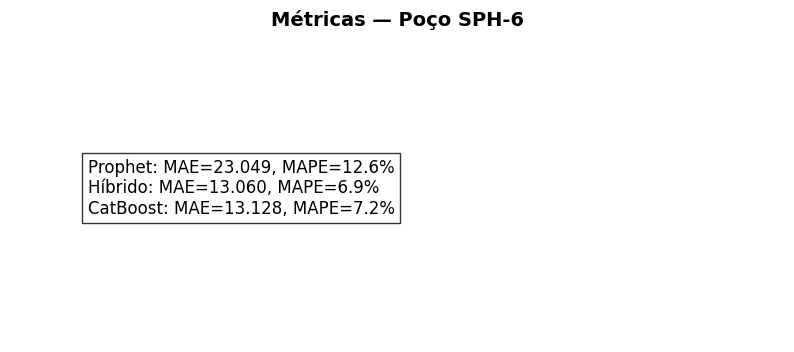

   📈 Plotando SPH-8...


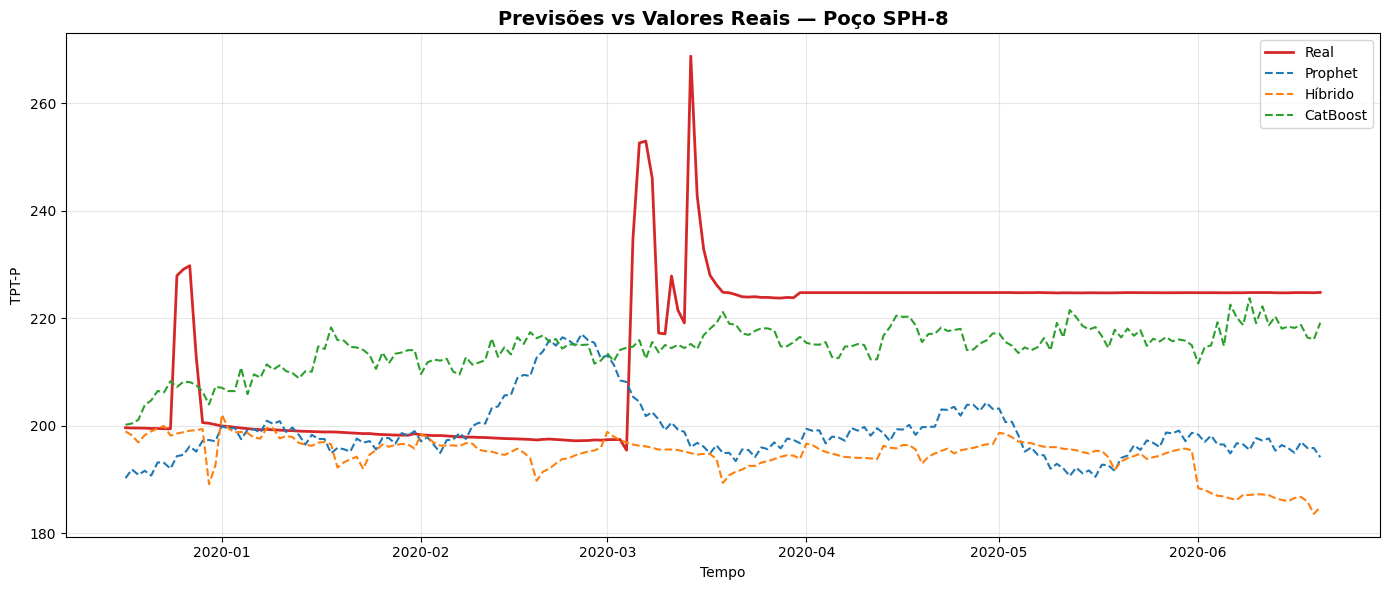

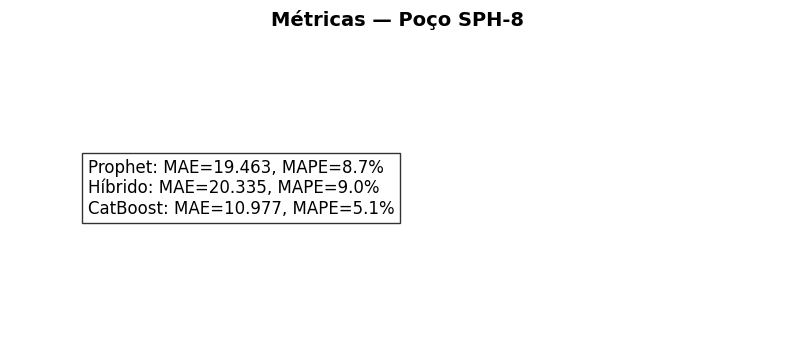

✅ Gráficos individuais criados com sucesso!


In [ ]:
# 📊 Visualização Comparativa dos Modelos (Prophet, Híbrido, CatBoost)

print("\n" + "="*80)
print("📊 CRIANDO VISUALIZAÇÕES COMPARATIVAS — Prophet x Híbrido x CatBoost")
print("="*80)

import matplotlib.pyplot as plt
import numpy as np

# CONFIGURAÇÕES
plt.style.use('default')
colors = {
    'Prophet': '#1f77b4',     # Azul
    'Híbrido': '#ff7f0e',     # Laranja
    'CatBoost': '#2ca02c',    # Verde
    'Real': '#d62728'         # Vermelho
}
results_dict = {}
for _, row in results.iterrows():
    results_dict[row['poco']] = {
        'metrics': {
            'Prophet': {'MAE': row['Prophet_MAE'], 'MAPE': row['Prophet_MAPE']},
            'Híbrido': {'MAE': row['Hibrido_MAE'], 'MAPE': row['Hibrido_MAPE']},
            'CatBoost': {'MAE': row['CatBoost_MAE'], 'MAPE': row['CatBoost_MAPE']}
        }
    }

# Prepara dados comparativos
model_comparison = {m: [] for m in ['Prophet', 'Híbrido', 'CatBoost']}
for poco, res in results_dict.items():
    for model in model_comparison.keys():
        if not np.isnan(res['metrics'][model]['MAE']):
            model_comparison[model].append(res['metrics'][model]['MAE'])

#FIGURA GERAL
print("\n📈 Criando gráfico geral de performance por poço...")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparação de Modelos de Predição — Prophet | Híbrido | CatBoost',
             fontsize=16, fontweight='bold')

# ---------- Subplot 1: MAE por poço ----------
well_names = list(results_dict.keys())
x_pos = np.arange(len(well_names))
width = 0.25

for i, model in enumerate(['Prophet', 'Híbrido', 'CatBoost']):
    maes = [results_dict[p]['metrics'][model]['MAE'] for p in well_names]
    ax1.bar(x_pos + i * width, maes, width, label=model, color=colors[model], alpha=0.8)

ax1.set_xlabel('Poços')
ax1.set_ylabel('MAE (Mean Absolute Error)')
ax1.set_title('MAE por Poço e Modelo')
ax1.set_xticks(x_pos + width)
ax1.set_xticklabels(well_names, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ---------- Subplot 2: Boxplot das performances ----------
valid_model_data = []
valid_model_labels = []
for model_name, mae_values in model_comparison.items():
    if mae_values:
        valid_model_data.append(mae_values)
        valid_model_labels.append(model_name)

if valid_model_data:
    bp = ax2.boxplot(valid_model_data, labels=valid_model_labels, patch_artist=True)
    for patch, model in zip(bp['boxes'], valid_model_labels):
        patch.set_facecolor(colors[model])
        patch.set_alpha(0.7)

ax2.set_ylabel('MAE Distribution')
ax2.set_title('Distribuição de Performance dos Modelos')
ax2.grid(True, alpha=0.3)

# ---------- Subplot 3: Performance média ----------
avg_maes = {m: np.mean(vals) for m, vals in model_comparison.items() if vals}
std_maes = {m: np.std(vals) for m, vals in model_comparison.items() if vals}

if avg_maes:
    models = list(avg_maes.keys())
    avg_values = list(avg_maes.values())
    std_values = [std_maes[m] for m in models]

    bars = ax3.bar(models, avg_values, yerr=std_values, capsize=5,
                   color=[colors[m] for m in models], alpha=0.8)

    for bar, value in zip(bars, avg_values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

ax3.set_ylabel('MAE Médio')
ax3.set_title('Performance Média dos Modelos')
ax3.grid(True, alpha=0.3)

# ---------- Subplot 4: Tabela de resumo ----------
ax4.axis('tight')
ax4.axis('off')

headers = ['Modelo', 'MAE Médio', 'Desvio Padrão', 'Min MAE', 'Max MAE', 'Poços Válidos']
table_data = []

for model in ['Prophet', 'Híbrido', 'CatBoost']:
    if model in model_comparison and model_comparison[model]:
        vals = model_comparison[model]
        row = [
            model,
            f"{np.mean(vals):.3f}",
            f"{np.std(vals):.3f}",
            f"{np.min(vals):.3f}",
            f"{np.max(vals):.3f}",
            f"{len(vals)}"
        ]
        table_data.append(row)

if table_data:
    table = ax4.table(cellText=table_data, colLabels=headers,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    # color header
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')

    # alternate row colors
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#f1f1f2')

ax4.set_title('Resumo Estatístico dos Modelos', pad=20)

plt.tight_layout()
plt.show()

print("✅ Gráfico geral criado com sucesso!")


# %% [markdown]
# 📊 Gráficos Individuais — Predição vs Real (3 primeiros poços)

print(f"\n📊 Criando gráficos individuais para os primeiros poços...")

for i, (_, row) in enumerate(results.iterrows()):
    if i >= 3:  # apenas os 3 primeiros poços
        break

    well_name = row["poco"]
    print(f"   📈 Plotando {well_name}...")

    plt.figure(figsize=(14, 6))

    # Plot dados reais e predições
    plt.plot(row["test_dates"], row["y_true"], color=colors["Real"], label="Real", linewidth=2)
    plt.plot(row["test_dates"], row["yhat_prophet"], color=colors["Prophet"], linestyle="--", label="Prophet")
    plt.plot(row["test_dates"], row["yhat_hibrido"], color=colors["Híbrido"], linestyle="--", label="Híbrido")
    plt.plot(row["test_dates"], row["yhat_cat"], color=colors["CatBoost"], linestyle="--", label="CatBoost")

    plt.title(f"Previsões vs Valores Reais — Poço {well_name}", fontsize=14, fontweight="bold")
    plt.xlabel("Tempo")
    plt.ylabel(PARAMETRO_ALVO)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Bloco de métricas
    metrics_text = (
        f"Prophet: MAE={row['Prophet_MAE']:.3f}, MAPE={row['Prophet_MAPE']:.1f}%\n"
        f"Híbrido: MAE={row['Hibrido_MAE']:.3f}, MAPE={row['Hibrido_MAPE']:.1f}%\n"
        f"CatBoost: MAE={row['CatBoost_MAE']:.3f}, MAPE={row['CatBoost_MAPE']:.1f}%"
    )

    plt.figure(figsize=(10, 4))
    plt.axis("off")
    plt.text(0.1, 0.5, metrics_text, fontsize=12,
             bbox=dict(facecolor="white", alpha=0.8),
             verticalalignment="center", transform=plt.gca().transAxes)
    plt.title(f"Métricas — Poço {well_name}", fontsize=14, fontweight="bold")
    plt.show()

print("✅ Gráficos individuais criados com sucesso!")


In [ ]:
# 🎯 ANÁLISE FINAL E CONCLUSÕES — Prophet x Híbrido x CatBoost
print("\n" + "="*80)
print("🎯 ANÁLISE FINAL DOS RESULTADOS")
print("="*80)

# 1️⃣ Ranking dos modelos (por MAE médio)

print("\n🏆 RANKING FINAL DOS MODELOS:")
print("-" * 50)

if avg_maes:
    ranked_models = sorted(avg_maes.items(), key=lambda x: x[1])

    for rank, (model_name, avg_mae) in enumerate(ranked_models, 1):
        model_values = model_comparison[model_name]
        std_mae = np.std(model_values)
        success_rate = len(model_values) / len(results) * 100

        medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉"
        print(f"{medal} {rank}º lugar: {model_name}")
        print(f"   MAE médio: {avg_mae:.4f} ± {std_mae:.4f}")
        print(f"   Taxa de sucesso: {success_rate:.1f}% ({len(model_values)}/{len(results)} poços)")
        print()


# 2️⃣ Análise por poço — qual modelo venceu em cada um

print("📊 ANÁLISE POR POÇO:")
print("-" * 50)

# Contador de vitórias por modelo
model_wins = {"Prophet": 0, "Híbrido": 0, "CatBoost": 0}
detailed_results = []

for _, row in results.iterrows():
    # Organiza os resultados de cada modelo para esse poço
    model_metrics = {
        "Prophet": row.get("Prophet_MAE", np.nan),
        "Híbrido": row.get("Hibrido_MAE", np.nan),
        "CatBoost": row.get("CatBoost_MAE", np.nan)
    }

    # Ignora poços sem métricas válidas
    valid_models = {m: v for m, v in model_metrics.items() if not np.isnan(v)}
    if not valid_models:
        continue

    # Escolhe o menor MAE
    best_model = min(valid_models, key=valid_models.get)
    best_mae = valid_models[best_model]
    best_mape = row[f"{'Hibrido' if best_model=='Híbrido' else best_model}_MAPE"]

    model_wins[best_model] += 1
    detailed_results.append({
        "poco": row["poco"],
        "best_model": best_model,
        "best_mae": best_mae,
        "best_mape": best_mape
    })

    print(f"📍 {row['poco']}: {best_model} (MAE: {best_mae:.4f})")

print(f"\n🏆 VITÓRIAS POR MODELO:")
for model, wins in model_wins.items():
    percentage = wins / len(detailed_results) * 100 if detailed_results else 0
    print(f"   {model}: {wins} vitórias ({percentage:.1f}%)")

# 3️⃣ Insights e recomendações

print(f"\n💡 INSIGHTS E RECOMENDAÇÕES:")
print("-" * 50)

if avg_maes:
    best_model = min(avg_maes.items(), key=lambda x: x[1])
    most_wins = max(model_wins.items(), key=lambda x: x[1])

    print(f"✅ Modelo com melhor performance média: {best_model[0]}")
    print(f"✅ Modelo com mais vitórias individuais: {most_wins[0]}")

    if best_model[0] == most_wins[0]:
        print(f"🎯 CONCLUSÃO: O modelo {best_model[0]} é consistentemente o melhor!")
    else:
        print(f"🤔 OBSERVAÇÃO: Há diferença entre performance média e vitórias individuais.")

    print(f"\n📈 CARACTERÍSTICAS DOS MODELOS:")
    print(f"   🔵 Prophet: Captura tendências e sazonalidades suavizadas, ideal para séries temporais estáveis.")
    print(f"   🟠 Híbrido Prophet+LGBM: Combina o aprendizado temporal do Prophet com a correção residual do LGBM.")
    print(f"   🟢 CatBoost: Modelo de boosting puro, poderoso para capturar relações não-lineares.")

    # Recomendações baseadas nos resultados
    if best_model[0] == "Prophet":
        print(f"\n💼 RECOMENDAÇÃO: O Prophet teve desempenho mais robusto.")
        print(f"   Ideal para séries com padrão sazonal e poucos ruídos extremos.")
    elif best_model[0] == "Híbrido":
        print(f"\n💼 RECOMENDAÇÃO: O modelo híbrido foi o mais eficaz.")
        print(f"   Sugere que combinar previsões do Prophet com LGBM melhora a captura de padrões complexos.")
    else:
        print(f"\n💼 RECOMENDAÇÃO: O CatBoost apresentou o menor erro médio.")
        print(f"   Indicado quando há comportamentos não lineares e maior variabilidade.")

    print(f"\n📊 MÉTRICAS FINAIS:")
    print(f"   Total de poços analisados: {len(results)}")
    print(f"   Modelos implementados: 3")
    print(f"   MAE médio geral: {np.mean([mae for maes in model_comparison.values() for mae in maes]):.4f}")

# ---------------------------------------------------------------------
# 4️⃣ Resumo e conclusão
# ---------------------------------------------------------------------
print(f"\n💾 Resumo disponível em 'results' (DataFrame com métricas e previsões).")
print(f"   Colunas: ['poco', 'Prophet_MAE', 'Hibrido_MAE', 'CatBoost_MAE', 'MAPE', 'y_true', ...]")
print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)



🎯 ANÁLISE FINAL DOS RESULTADOS

🏆 RANKING FINAL DOS MODELOS:
--------------------------------------------------
🥇 1º lugar: Híbrido
   MAE médio: 25.6184 ± 25.5939
   Taxa de sucesso: 100.0% (6/6 poços)

🥈 2º lugar: CatBoost
   MAE médio: 30.5808 ± 24.8001
   Taxa de sucesso: 100.0% (6/6 poços)

🥉 3º lugar: Prophet
   MAE médio: 42.9695 ± 33.8675
   Taxa de sucesso: 100.0% (6/6 poços)

📊 ANÁLISE POR POÇO:
--------------------------------------------------
📍 LL-22: Híbrido (MAE: 10.9762)
📍 SPH-6: Híbrido (MAE: 13.0605)
📍 SPH-8: CatBoost (MAE: 10.9774)
📍 LL-11: Híbrido (MAE: 12.1660)
📍 SPS-77: CatBoost (MAE: 11.5596)
📍 SPH-2: CatBoost (MAE: 79.7584)

🏆 VITÓRIAS POR MODELO:
   Prophet: 0 vitórias (0.0%)
   Híbrido: 3 vitórias (50.0%)
   CatBoost: 3 vitórias (50.0%)

💡 INSIGHTS E RECOMENDAÇÕES:
--------------------------------------------------
✅ Modelo com melhor performance média: Híbrido
✅ Modelo com mais vitórias individuais: Híbrido
🎯 CONCLUSÃO: O modelo Híbrido é consistentemente o 

In [ ]:
# Caminho de saída (ajuste o nome se quiser identificar o experimento)
RESULTS_CSV_PATH = "resultados_prophet_hibrido_catboost.csv"

# Salvar resultados em CSV
results.to_csv(RESULTS_CSV_PATH, index=False, encoding='utf-8-sig')
print(f"✅ Resultados salvos em: {RESULTS_CSV_PATH}")


✅ Resultados salvos em: resultados_prophet_hibrido_catboost.csv


In [ ]:
from google.colab import files
files.download("resultados_prophet_hibrido_catboost.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>